# Hydrology 12320 - Tutorial 1 - Solutions
## Question 1
### a)

The transient water balance of the aquifer before pumping starts reads

$ \frac{dSto}{dt} =  q_r - Out$

where $Sto$ is the volume of freshwater stored in the aquifer ($L^{3}$), $t$ is time ($T$), $q_r$ is the rate of recharge ($L^3/T$) and $Out$ is the outflow ($L^3/T$).

### b)

The steady‐state water balance reads:
    
$0 = q_r - Out$

Using the linear reservoir assumption for the outflow, we get:

$0 = q_r -\frac{1}{\tau}Sto$

so:

$\tau = \frac{Sto}{q_r}$

and the numerical result is:

In [1]:
Sto = 50 # in km^3
q_r = 0.015 # in km^3/yr
tau = Sto/q_r
print('tau = ', round(tau,1), 'in years')

tau =  3333.3 in years


### c)

The transient water balance of the aquifer after pumping starts reads

$\frac{dSto}{dt} = q_r - Out - Q$

where $Q$ is the pumping rate in ($L^3/T$).

### d)

We use the linear reservoir assumption and thus have to solve the following differential equation:

$\frac{dSto}{dt} = q_r - \frac{1}{\tau}Sto - Q$

That is a differential equation of the general form:

$\frac{dy}{dt}=-ay + b$

This is a linear, first‐order inhomogeneous differential equation. The solution to such an equation can be formulated as:

$y = Cy_h + y_s$

where $y_h$ is the solution to the homogeneous problem $\left(\frac{dy}{dt} = -ay\right)$, $y_s$ is one special solution to the inhomogeneous problem (to be guessed) and $C$ is a free constant to be determined from initial conditions.

The solution to the homogeneous problem is:

$y_h = \exp(-at)$

We can guess a special solution by looking at steady state:

$0= -ay_s + b$ i.e.
$y_s = \frac{b}{a}$

The general solution is thus

$y = C\exp(-at) + \frac{b}{a}$

For our problem the solution is:

$Sto(t) = C \exp\left(-\frac{t}{\tau}\right)+\tau(q_r - Q)$

$C$ is solved through the initial conditions $t=0$ with $Sto(0)=Sto_{ini}$, from which follows:

$C=Sto_{ini}-\tau(q_r-Q)$

and finally:

$Sto(t) = \left[Sto_{ini}-\tau\left(q_r-Q\right)\right] \exp\left(-\frac{t}{\tau}\right)+\tau(q_r - Q)$

From this, we see that the volume will decrease exponentially with time. Solving the equation for $t=\infty$ gives the solution:

$Sto(\infty) = \tau(q_r - Q)$

with the numerical solution:

In [2]:
Q = 0.01 # in km^3/year
Sto_inf = tau * (q_r - Q)
print('Sto_inf = ',round(Sto_inf,1),'in km^3')

Sto_inf =  16.7 in km^3


### e)

Assuming $Out=0$ simplifies the differential equation for the storage to:

$\frac{dSto}{dt} = q_r -Q$

The solution for this equation is:

$Sto(t) = Sto_{ini} + (q_r - Q)t$

To calculate the time until storage depletion, we set $Sto(t) = 0$ and solve for $t$:

$t = \frac{Sto_{ini}}{Q-q_r}$

The numerical solution is:

In [3]:
Q_new = 0.12 #in km^3/yr
t = Sto/(Q_new-q_r)
print('t until storage is empty = ',round(t,1),'in years')

t until storage is empty =  476.2 in years


## Question 2
### a)

The transient water balance is:

$\frac{dSto}{dt}=In -E\cdot A$

Where $Sto$ is the water volume in the sea ($L^3$), $t$ is time ($T$), $In$ is the inflow ($L^3/T$), $E$ is the evaporation rate ($L/T$) and $A$ is the surface area of the sea ($L^2$).

### b)

The steady state water balance is:

$0=In-E\cdot A$

### c)

Solving the steady state water balance for $A$ gives:

$A=\frac{In}{E}$

To calculate the area numerically, the annual totals from the excel spreadsheet are used:

In [4]:
import pandas
import numpy as np

data = pandas.read_excel(r'Tutorial_1.xlsx','Sheet1')
In_tot = np.sum(data['Inflow (million m3)'])*10**6 #total inflow in m^3/year
E_tot = np.sum(data['Evaporation (mm)'])/10**3 #total evaporation in m/year
A = In_tot/E_tot/10**6 #Area in km^2
print('Area A = ',round(A,1),'in km^2')

Area A =  786.3 in km^2


### d)

Formulate discrete form of the transient water balance equation:

$Sto_{t+1}=Sto_t + (In - E\cdot A) \Delta t$

To solve this numerical, the storage and water level are calculated for each month:

Amplitude =  0.276 in m


Text(0, 0.5, 'Water level in cm')

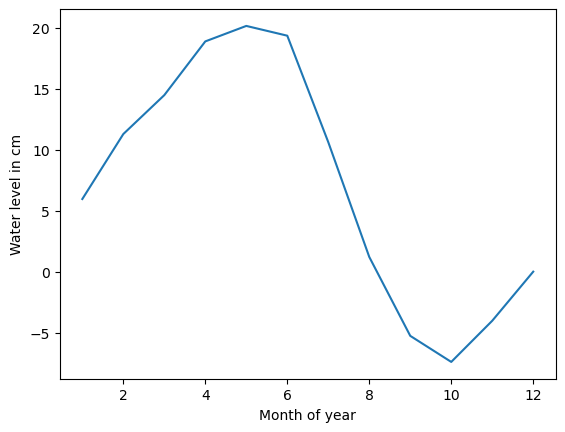

In [5]:
# First month with initial storage and water level = 0
Storage=np.zeros(12) #Initialize Storage (million m^3)
Storage[0]=data['Inflow (million m3)'][0]-data['Evaporation (mm)'][0]*A/1000
for i in range(1,12): #calculate rest of the month
    Storage[i]=(Storage[i-1]+data['Inflow (million m3)'][i]-
    data['Evaporation (mm)'][i]*A/1000)
Water_level=Storage/A
amplitude=Water_level.max()-Water_level.min() #Amplitude in m
print('Amplitude = ',round(amplitude,3),'in m')

#Plotting the Water_level
%matplotlib inline
import matplotlib.pyplot as pl
pl.plot(range(1,13),Water_level*100)
pl.xlabel('Month of year')
pl.ylabel('Water level in cm')

We considered an initial storage Sto=0, that is why some months have a negative water level. Try to put a reasonable value (in relation to the extent of lake area  A*water depth) and the water level will be positive. The amplitude of course stays the same.